# 02 · ОДУ

Одиночные обыкновенные дифференциальные уравнения: вынужденный осциллятор, Ван дер Поль, Дуффинг. В каждом разделе: данные, проверка сигнала при шуме 0/1/5 % и запуск поиска без шума и с шумом 5 %.

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


## `ode` · Вынужденный осциллятор с переменным затуханием

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.


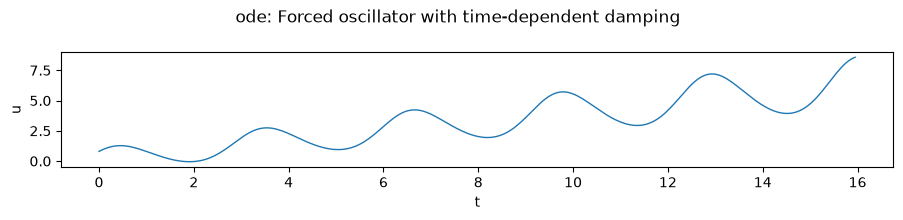

In [2]:
p = datasets.load('ode')
print(p.summary())
plot_problem(p); plt.show()

In [3]:
p, report = check('ode', noise_levels=[0, 1, 5])
print_check(p, report)

ode: Forced oscillator with time-dependent damping
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -4.0 * u{power: 1.0} + -1.0 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 1.5 * x{power: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + sin(2t) u' + 4u = 1.5t on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 0.999831   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  u{'power': 1.0}                                                    -4      -3.9845            9.119e-01
  du/dx0{'power': 1.0} * sin{'power': 1.0, 'freq': 2.0, 'dim         -1     -0.98892            5.823e-02
  x{'power': 1.0, 'dim': 0.0}                                       1.5       1.4974            5.044e-01

=== noise 1 % ===
R^2 of the true structure: 0.433371   (d^2u/dx0^2{power: 1.0})
  term            

In [4]:
from epde_bench.nbcache import cached_run
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 40 s (from cache)
[0] <- compromise pick
     -3.984485683554886 * u{power: 1.0} + 1.496973458999215 * x{power: 1.0, dim: 0.0} + -0.9885206385764294 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.005791878178457512}


In [5]:
from epde_bench.nbcache import cached_run
rec = cached_run('ode', variant='default', noise=5.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok

 fit 37 s (from cache)
[0] <- compromise pick
     0.3776719262905246 * du/dx0{power: 1.0} * x{power: 1.0, dim: 0.0} + -0.026752185511043605 * u{power: 3.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.015931012500262246 * u{power: 3.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     2.296267887408089 * u{power: 1.0} * d^2u/dx0^2{power: 1.0} + 24.55562608132476 * u{power: 2.0} + -20.573826506859827 * u{power: 1.0} * x{power: 1.0, dim: 0.0} + 4.178285440518317 * x{power: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0} * x{power: 1.0, dim: 0.0}
{'front_size': 2, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


## `vdp` · Осциллятор Ван дер Поля (mu = 0.2)

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.


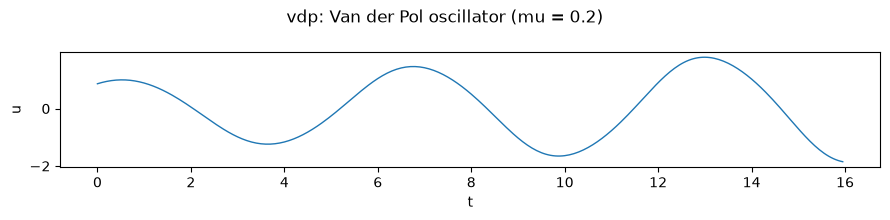

In [6]:
p = datasets.load('vdp')
print(p.summary())
plot_problem(p); plt.show()

In [7]:
p, report = check('vdp', noise_levels=[0, 1, 5])
print_check(p, report)

vdp: Van der Pol oscillator (mu = 0.2)
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (320,); variables: u
  t: [0, 15.95], 320 points
  truth:
    -0.2 * u{power: 2.0} * du/dx0{power: 1.0} + 0.2 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' = 0.2 (1 - u^2) u' - u on t in [0, 16), dt = 0.05.

=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0} * u{'power': 2.0}                           -0.2     -0.19902            1.745e-02
  du/dx0{'power': 1.0}                                              0.2      0.19933            1.975e-02
  u{'power': 1.0}                                                    -1     -0.99957            9.775e-01

=== noise 1 % ===
R^2 of the true structure: 0.142966   (d^2u/dx0^2{power: 1.0})
  term                                                      

In [8]:
from epde_bench.nbcache import cached_run
rec = cached_run('vdp', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok

 fit 80 s (from cache)
[0] <- compromise pick
     0.1993272458603458 * du/dx0{power: 1.0} + -0.19902156571275761 * du/dx0{power: 1.0} * u{power: 2.0} + -0.9995698877465794 * u{power: 1.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.0028953514626345322}


In [9]:
from epde_bench.nbcache import cached_run
rec = cached_run('vdp', variant='default', noise=5.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 77 s (from cache)
[0]
     0.10758555645810121 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + -0.0839714248541288 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[1]
     0.10055168184353737 * u{power: 2.0} * x{power: 1.0, dim: 0.0} + -0.1919939301089809 * x{power: 1.0, dim: 0.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + -0.012609848342927681 * x{power: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
[2] <- compromise pick
     0.00895608186282936 * x{power: 2.0, dim: 0.0} + -0.005564932540603038 * x{power: 2.0, dim: 0.0} * u{power: 2.0} + 0.16440101294320794 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 2, 'success_front': False, 'success_selected': False, 'hamming_min': 7, 'hamming_selected': 8, 'coef_error': None}


## `duffing` · Осциллятор Дуффинга с вынуждающей силой

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); parameters stored in the file (as in projects/pinn/gate.py).


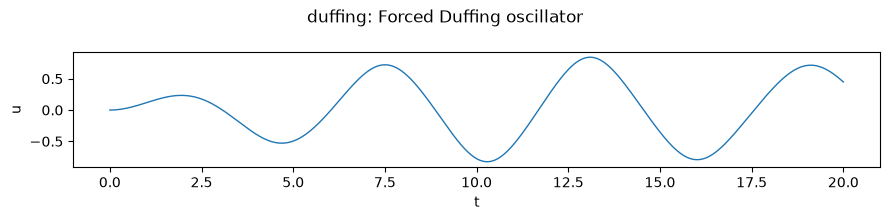

In [10]:
p = datasets.load('duffing')
print(p.summary())
plot_problem(p); plt.show()

In [11]:
p, report = check('duffing', noise_levels=[0, 1, 5])
print_check(p, report)

duffing: Forced Duffing oscillator
  class: ODE (one equation), source: synthetic
  axes: t; data shape: (1001,); variables: u
  t: [0, 20], 1001 points
  truth:
    -0.20000000298023224 * du/dx0{power: 1.0} + -1.0 * u{power: 1.0} + -1.0 * u{power: 3.0} + 0.30000001192092896 * cos{power: 1.0, freq: 1.0, dim: 0.0} = d^2u/dx0^2{power: 1.0}
  notes: u'' + delta u' + alpha u + beta u^3 = gamma cos(omega t); parameters stored in the file (as in projects/pinn/gate.py).



=== noise 0 % ===
R^2 of the true structure: 1.000000   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0}                                             -0.2     -0.19988            1.137e-02
  u{'power': 1.0}                                                    -1      -1.0003            9.384e-02
  u{'power': 3.0}                                                    -1     -0.99866            2.239e-02
  cos{'power': 1.0, 'freq': 1.0, 'dim': 0.0}                        0.3      0.29983            2.591e-02

=== noise 1 % ===
R^2 of the true structure: 0.009236   (d^2u/dx0^2{power: 1.0})
  term                                                             true       fitted  R^2 lost if dropped
  du/dx0{'power': 1.0}                                             -0.2     -0.38464            3.654e-04
  u{'power': 1.0}                                                    -1     -0.79928         

In [12]:
from epde_bench.nbcache import cached_run
rec = cached_run('duffing', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok

 fit 100 s (from cache)
[0] <- compromise pick
     -0.42740229414932496 * d^2u/dx0^2{power: 2.0} + -0.5707580731150578 * u{power: 2.0} + 0.0 = u{power: 1.0} * d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 8, 'hamming_selected': 8, 'coef_error': None}


In [13]:
from epde_bench.nbcache import cached_run
rec = cached_run('duffing', variant='default', noise=5.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 291 s (from cache)
[0]
     -0.00974686521533911 * u{power: 1.0} * x{power: 2.0, dim: 0.0} + 0.12606074697526562 * x{power: 1.0, dim: 0.0} * cos{power: 1.0, freq: 1.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0}
[1] <- compromise pick
     0.02284055368677974 * x{power: 1.0, dim: 0.0} + -0.03433220133486359 * x{power: 1.0, dim: 0.0} * u{power: 2.0} + 0.5271984616628808 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * u{power: 1.0}
[2]
     -0.03467351168629306 * x{power: 1.0, dim: 0.0} * u{power: 2.0} + -0.0004872078088334357 * d^2u/dx0^2{power: 1.0} * cos{power: 1.0, freq: 1.0, dim: 0.0} + 0.5274595661250028 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.0, dim: 0.0} + 0.022935800980566936 * x{power: 1.0, dim: 0.0} + 0.0 = u{power: 1.0} * du/dx0{power: 1.0}
{'front_size': 3, 'selected_index': 1, 'success_front': False, 'success_selected': False, 'hamming_min': 6, 'hamming_selected': 9, 'coef_error': None}
